In [1]:
from solvers import *
from ct import ct_astra
from projectors import *
import csv
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize, radon
from trips.test_problems.Tomography import *
from skimage.metrics import structural_similarity as ssim
import matplotlib.ticker as mticker



settings
data already in the path.


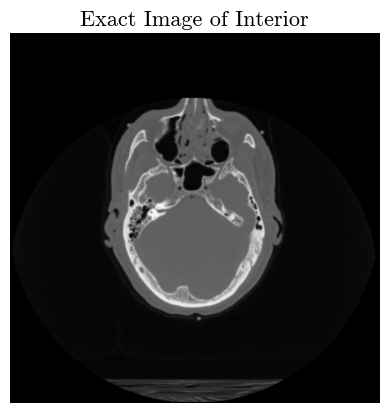

In [2]:
img_size = 1024

Tomo = Tomography()
(x_true, nx, ny) = Tomo.gen_true('head', nx =img_size, ny =img_size)
X = x_true.reshape(nx, ny).astype('float32')


plt.figure()
plt.imshow(X, cmap='gray')
plt.axis('off')
plt.title('Exact Image of Interior',fontname='cmr10',fontsize=16)
plt.show()

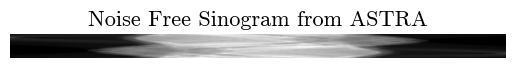

In [3]:
# CT setup
num_pixels      = np.shape(X)[0]    # Number of pixels in x/y direction (X needs to be square)
num_dets        = num_pixels        # Number of detector pixels
num_angles      = 50               # Number of projection angles
ang_start       = 0                 # Start angle in degress
ang_end         = 360               # End angle in degress
angles          = np.linspace(ang_start,ang_end,num_angles,dtype=int) / 180 * np.pi 
# %% ************************************ ASTRA ************************************
# Parameters for ASTRA
proj_model      = 'linear'          # The projection model: 'line', 'strip', or 'linear'
proj_geom       = 'fanflat'         # The projection geometry: 'parallel' or 'fanflat'
source_origin   = 1000              # Distance from source to origin/center
origin_det      = 0                 # Distance from origin/center to detector
det_width       = 1                 # Detector width
gpu             = True              # Construct unmatched normal equations: 'False' or 'True' 
ct = ct_astra(num_pixels,num_angles,num_dets,angles,proj_model,proj_geom,source_origin,origin_det,det_width,gpu)

# Create Sinogram
_, Bexact = astra.create_sino(X, ct.proj_id)
plt.figure()
plt.imshow(Bexact, cmap='gray')
plt.axis('off')
plt.title('Noise Free Sinogram from ASTRA',fontname='cmr10',fontsize=16)
plt.show()

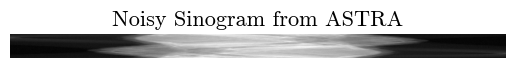

In [6]:
# Create noisy sinogram
rnl     = 0.015
e0      = np.random.normal(0.0, 1.0, ct.m)
e1      = e0/np.linalg.norm(e0)
bexact  = Bexact.reshape(-1)
e       = rnl*np.linalg.norm(bexact)*e1
b       = bexact + e
delta = np.std(e)
sino = b.reshape(num_angles,img_size)
plt.figure()
plt.imshow(sino, cmap='gray')
plt.title('Noisy Sinogram from ASTRA',fontname='cmr10',fontsize=16)
plt.axis('off')
plt.show()

A       = fp_astra(ct)     # The forward projector
B       = bp_astra(ct)     # The back projector  


In [ ]:
iter    = 100              # Maximum number of iterations
p = 0

X_AB, R_AB = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 0, delta = delta)
X_AB_l, R_AB_l = hybrid_AB_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 'lcurve', delta = delta)
X_AB_g, R_AB_g = hybrid_AB_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = p, regparam = 'gcv', delta = delta)

X_BA, R_BA = hybrid_BA_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 0, delta = delta)
X_BA_l, R_BA_l = hybrid_BA_GMRES(A,B,b,iter,ct.m, ct.n, ct.num_angles, p = p, regparam= 'lcurve', delta = delta)
X_BA_g, R_BA_g = hybrid_BA_GMRES(A,B,b,iter, ct.m, ct.n, ct.num_angles, p = p, regparam = 'gcv', delta = delta)




Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 5.9704 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 6.9029 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 12.6037 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 55.5529 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 56.7826 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 65.0874 seconds


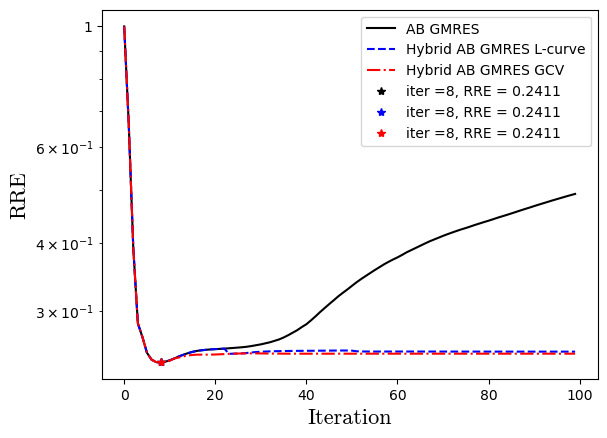

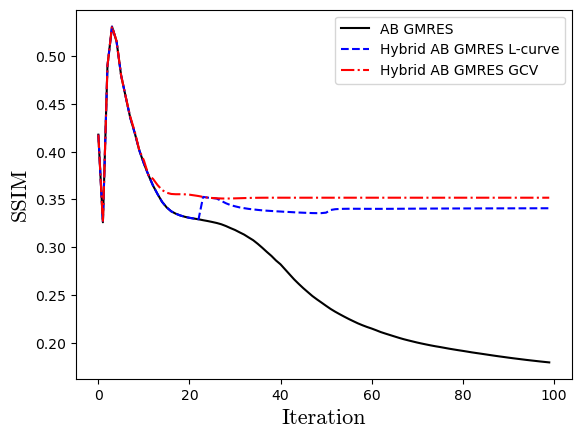

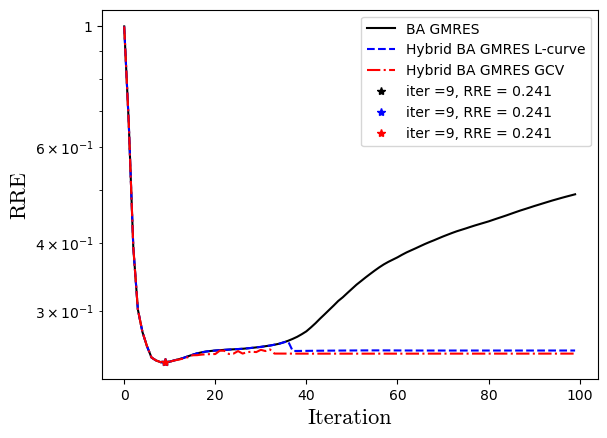

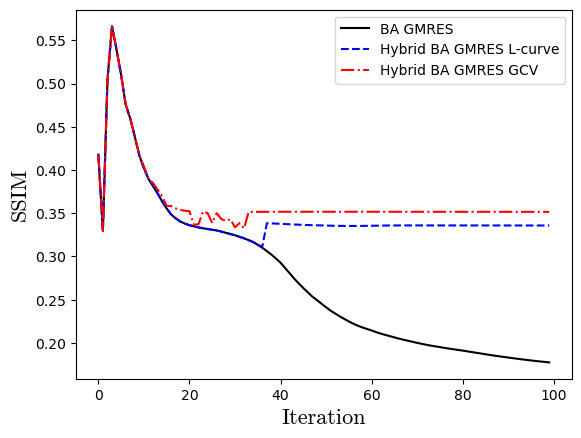

In [8]:
res_AB = np.zeros((iter,1))
res_AB_l = np.zeros((iter,1))
res_AB_g = np.zeros((iter,1))

ssim_AB = np.zeros((iter,1))
ssim_AB_l = np.zeros((iter,1))
ssim_AB_g = np.zeros((iter,1))


for i in range(0,iter):
    res_AB[i] = np.linalg.norm(X.reshape(-1) - X_AB[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB_l[i] = np.linalg.norm(X.reshape(-1) - X_AB_l[:,i])/np.linalg.norm(X.reshape(-1))
    res_AB_g[i] = np.linalg.norm(X.reshape(-1) - X_AB_g[:,i])/np.linalg.norm(X.reshape(-1))

X = X.reshape(num_pixels, num_pixels)
for i in range(0,iter):
    ssim_AB[i] = ssim(X, X_AB[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_AB_l[i] = ssim(X, X_AB_l[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_AB_g[i] = ssim(X, X_AB_g[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())

val_AB = np.min(res_AB)
val_AB_l = np.min(res_AB_l)    
val_AB_g = np.min(res_AB_g)

idx_AB = np.argmin(res_AB)
idx_AB_l = np.argmin(res_AB_l)
idx_AB_g = np.argmin(res_AB_g)

# Plotting
plt.figure()
plt.semilogy(range(0,iter),res_AB,'k-')
plt.semilogy(range(0,iter),res_AB_l,'b--')
plt.semilogy(range(0,iter),res_AB_g,'r-.')
plt.semilogy(idx_AB,val_AB,'k*')
plt.semilogy(idx_AB_l,val_AB_l,'b*')
plt.semilogy(idx_AB_g,val_AB_g,'r*')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))

plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['AB GMRES', 'Hybrid AB GMRES L-curve', 'Hybrid AB GMRES GCV',
            'iter ='+str(idx_AB)+', RRE = '+str(round(val_AB,4)),
            'iter ='+str(idx_AB_l)+', RRE = '+str(round(val_AB_l,4)),
            'iter ='+str(idx_AB_g)+', RRE = '+str(round(val_AB_g,4))]),
plt.show()

plt.figure()
plt.plot(range(0,iter),ssim_AB,'k-')
plt.plot(range(0,iter),ssim_AB_l,'b--')
plt.plot(range(0,iter),ssim_AB_g,'r-.')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('SSIM',fontname='cmr10',fontsize=16)
plt.legend(['AB GMRES', 'Hybrid AB GMRES L-curve', 'Hybrid AB GMRES GCV'])
plt.show()
res_BA = np.zeros((iter,1))
res_BA_l = np.zeros((iter,1))
res_BA_g = np.zeros((iter,1))


for i in range(0,iter):
    res_BA[i] = np.linalg.norm(X.reshape(-1) - X_BA[:,i])/np.linalg.norm(X.reshape(-1))
    res_BA_l[i] = np.linalg.norm(X.reshape(-1) - X_BA_l[:,i])/np.linalg.norm(X.reshape(-1))
    res_BA_g[i] = np.linalg.norm(X.reshape(-1) - X_BA_g[:,i])/np.linalg.norm(X.reshape(-1))

ssim_BA = np.zeros((iter,1))
ssim_BA_l = np.zeros((iter,1))
ssim_BA_g = np.zeros((iter,1))
for i in range(0,iter):
    ssim_BA[i] = ssim(X, X_BA[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_BA_l[i] = ssim(X, X_BA_l[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())
    ssim_BA_g[i] = ssim(X, X_BA_g[:,i].reshape(num_pixels, num_pixels), data_range=X.max() - X.min())


val_BA = np.min(res_BA)
val_BA_l = np.min(res_BA_l)
val_BA_g = np.min(res_BA_g)


idx_BA = np.argmin(res_BA)
idx_BA_l = np.argmin(res_BA_l)
idx_BA_g = np.argmin(res_BA_g)

# Plotting
plt.figure()
plt.semilogy(range(0,iter),res_BA,'k-')
plt.semilogy(range(0,iter),res_BA_l,'b--')
plt.semilogy(range(0,iter),res_BA_g,'r-.')
plt.semilogy(idx_BA,val_BA,'k*')
plt.semilogy(idx_BA_l,val_BA_l,'b*')
plt.semilogy(idx_BA_g,val_BA_g,'r*')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))

plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['BA GMRES', 'Hybrid BA GMRES L-curve', 'Hybrid BA GMRES GCV',
            'iter ='+str(idx_BA)+', RRE = '+str(round(val_BA,4)),
            'iter ='+str(idx_BA_l)+', RRE = '+str(round(val_BA_l,4)),
            'iter ='+str(idx_BA_g)+', RRE = '+str(round(val_BA_g,4))])
plt.show()
plt.figure()
plt.plot(range(0,iter),ssim_BA,'k-')
plt.plot(range(0,iter),ssim_BA_l,'b--')
plt.plot(range(0,iter),ssim_BA_g,'r-.')
plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('SSIM',fontname='cmr10',fontsize=16)
plt.legend(['BA GMRES', 'Hybrid BA GMRES L-curve', 'Hybrid BA GMRES GCV'])
plt.show()

In [8]:
regparam = 'lcurve'
iter = 100
p = 0

X_BA, R_BA = hybrid_BA_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, p = p, regparam=regparam)
X_AB, R_AB = hybrid_AB_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, p = p, regparam=regparam)

# Using DP as the stopping rule
# -------------------------------
stop_rule   = 'DP'          # The stopping criteria, DP = discrepancy principal
delta         = np.std(e)     # The noise level, when using DP as stopping criteria
X_BA_dp, R_BA_dp = hybrid_BA_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, delta = delta, p = p, regparam=regparam)
X_AB_dp, R_AB_dp = hybrid_AB_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, delta = delta, p = p, regparam=regparam)

# Using NCP as the stopping rule
# -------------------------------
stop_rule   = 'NCP'         # The stopping criteria, NCP = normalized cumulative periodogram
X_BA_ncp, R_BA_ncp = hybrid_BA_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, p = p, regparam=regparam)
X_AB_ncp, R_AB_ncp = hybrid_AB_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, p = p, regparam=regparam)


# Using RNS as the stopping rule
# -------------------------------

stop_rule   = 'RNS'         # The stopping criteria, RNS = Residual Norm Stagnation
X_BA_rns, R_BA_rns = hybrid_BA_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, p = p, regparam=regparam)
X_AB_rns, R_AB_rns = hybrid_AB_GMRES(A, B, b, iter, ct.m, ct.n, ct.num_angles, stop_rule = stop_rule, p = p, regparam=regparam)



Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 62.1872 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 10.1912 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 1.2759 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 0.8948 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 0.7797 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 0.4984 seconds

Hybrid-BA-GMRES is running
Hybrid BA-GMRES execution time: 28.7143 seconds

Hybrid-AB-GMRES is running
Hybrid AB-GMRES execution time: 3.0175 seconds


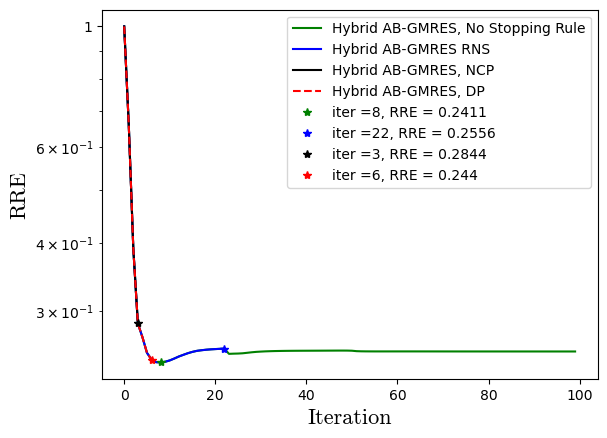

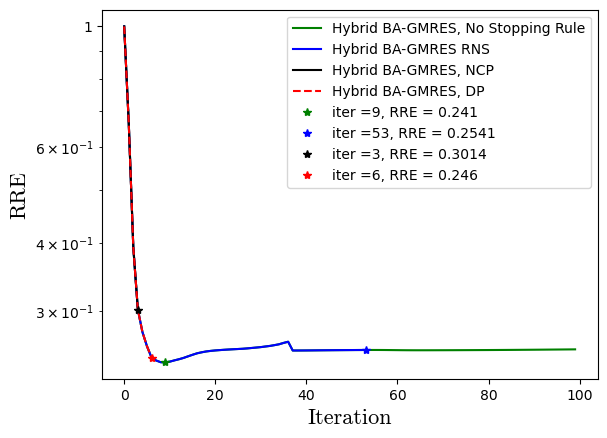

In [10]:
res_AB = np.zeros((iter, 1))
for i in range(0, iter):
    res_AB[i] = np.linalg.norm(X.reshape(-1) - X_AB[:,i])/np.linalg.norm(X.reshape(-1))
val_AB = np.min(res_AB)
idx_AB = np.argmin(res_AB)


# Errors of DP
iter_AB_dp = np.shape(X_AB_dp)[1] - 1
res_AB_dp = np.zeros((iter_AB_dp,1))
for i in range(0,iter_AB_dp):
    res_AB_dp[i] = np.linalg.norm(X.reshape(-1) - X_AB_dp[:,i])/np.linalg.norm(X.reshape(-1))
val_AB_dp = res_AB_dp[-1]
idx_AB_dp = iter_AB_dp - 1


# Errors of NCP
iter_AB_ncp = np.shape(X_AB_ncp)[1] - 1
res_AB_ncp = np.zeros((iter_AB_ncp,1))
for i in range(0,iter_AB_ncp):
    res_AB_ncp[i] = np.linalg.norm(X.reshape(-1) - X_AB_ncp[:,i])/np.linalg.norm(X.reshape(-1))
val_AB_ncp = res_AB_ncp[-1]
idx_AB_ncp = iter_AB_ncp - 1


# Errors of rns
iter_AB_rns = np.shape(X_AB_rns)[1] - 1
res_AB_rns = np.zeros((iter_AB_rns,1))
for i in range(0,iter_AB_rns):
    res_AB_rns[i] = np.linalg.norm(X.reshape(-1) - X_AB_rns[:,i])/np.linalg.norm(X.reshape(-1))
val_AB_rns = res_AB_rns[-1]
idx_AB_rns = iter_AB_rns - 1


# Plotting
plt.figure()
plt.semilogy(range(0,iter),res_AB,'g-')
plt.semilogy(range(0,iter_AB_rns),res_AB_rns,'b-')
plt.semilogy(range(0,iter_AB_ncp),res_AB_ncp,'k-')
plt.semilogy(range(0,iter_AB_dp),res_AB_dp,'r--')

plt.semilogy(idx_AB,val_AB,'g*')
plt.semilogy(idx_AB_rns,val_AB_rns,'b*')
plt.semilogy(idx_AB_ncp,val_AB_ncp,'k*')
plt.semilogy(idx_AB_dp,val_AB_dp,'r*')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))

plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['Hybrid AB-GMRES, No Stopping Rule', 'Hybrid AB-GMRES RNS','Hybrid AB-GMRES, NCP','Hybrid AB-GMRES, DP',
            'iter ='+str(idx_AB)+', RRE = '+str(round(val_AB,4)),
            'iter ='+str(idx_AB_rns)+', RRE = '+str(round(val_AB_rns[0],4)),
            'iter ='+str(idx_AB_ncp)+', RRE = '+str(round(val_AB_ncp[0],4)),
            'iter ='+str(idx_AB_dp)+', RRE = '+str(round(val_AB_dp[0],4))
])
plt.show()


res_BA = np.zeros((iter, 1))
for i in range(0, iter):
    res_BA[i] = np.linalg.norm(X.reshape(-1) - X_BA[:,i])/np.linalg.norm(X.reshape(-1))
val_BA = np.min(res_BA)
idx_BA = np.argmin(res_BA)

# Errors of DP
iter_BA_dp = np.shape(X_BA_dp)[1] - 1
res_BA_dp = np.zeros((iter_BA_dp,1))
for i in range(0,iter_BA_dp):
    res_BA_dp[i] = np.linalg.norm(X.reshape(-1) - X_BA_dp[:,i])/np.linalg.norm(X.reshape(-1))
val_BA_dp = res_BA_dp[-1]
idx_BA_dp = iter_BA_dp - 1

# Errors of NCP
iter_BA_ncp = np.shape(X_BA_ncp)[1] - 1
res_BA_ncp = np.zeros((iter_BA_ncp,1))
for i in range(0,iter_BA_ncp):
    res_BA_ncp[i] = np.linalg.norm(X.reshape(-1) - X_BA_ncp[:,i])/np.linalg.norm(X.reshape(-1))
val_BA_ncp = res_BA_ncp[-1]
idx_BA_ncp = iter_BA_ncp - 1

# Errors of rns
iter_BA_rns = np.shape(X_BA_rns)[1] - 1
res_BA_rns = np.zeros((iter_BA_rns,1))
for i in range(0,iter_BA_rns):
    res_BA_rns[i] = np.linalg.norm(X.reshape(-1) - X_BA_rns[:,i])/np.linalg.norm(X.reshape(-1))
val_BA_rns = res_BA_rns[-1]
idx_BA_rns = iter_BA_rns - 1

# Plotting
plt.figure()
plt.semilogy(range(0,iter),res_BA,'g-')
plt.semilogy(range(0,iter_BA_rns),res_BA_rns,'b-')
plt.semilogy(range(0,iter_BA_ncp),res_BA_ncp,'k-')
plt.semilogy(range(0,iter_BA_dp),res_BA_dp,'r--')

plt.semilogy(idx_BA,val_BA,'g*')
plt.semilogy(idx_BA_rns,val_BA_rns,'b*')
plt.semilogy(idx_BA_ncp,val_BA_ncp,'k*')
plt.semilogy(idx_BA_dp,val_BA_dp,'r*')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:g}'))

plt.xlabel('Iteration',fontname='cmr10',fontsize=16)
plt.ylabel('RRE',fontname='cmr10',fontsize=16)
plt.legend(['Hybrid BA-GMRES, No Stopping Rule', 'Hybrid BA-GMRES RNS','Hybrid BA-GMRES, NCP','Hybrid BA-GMRES, DP',
            'iter ='+str(idx_BA)+', RRE = '+str(round(val_BA,4)),
            'iter ='+str(idx_BA_rns)+', RRE = '+str(round(val_BA_rns[0],4)),
            'iter ='+str(idx_BA_ncp)+', RRE = '+str(round(val_BA_ncp[0],4)),
            'iter ='+str(idx_BA_dp)+', RRE = '+str(round(val_BA_dp[0],4))]
)
plt.show()


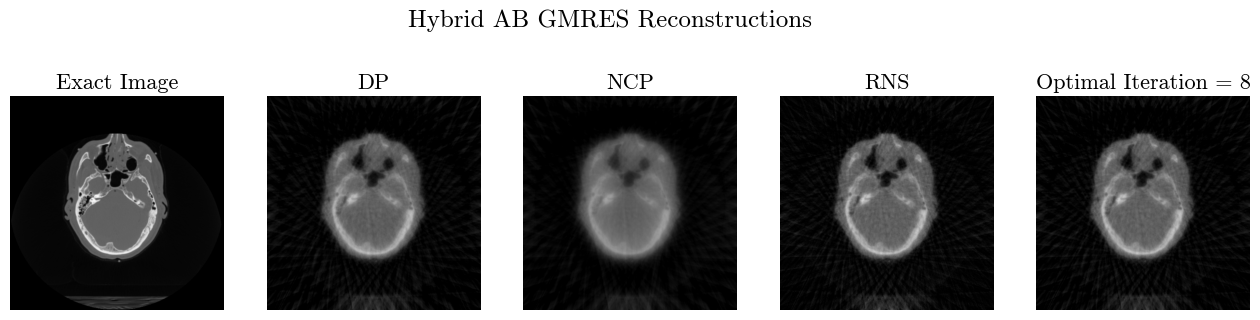

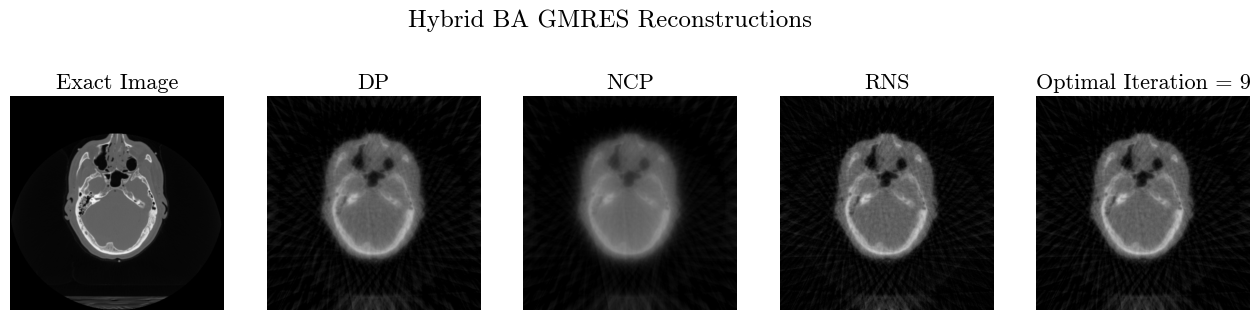

In [13]:
fig, axs = plt.subplots(1,5, figsize=(16,4))
xmin = np.min(X)
xmax = np.max(X)
im0 = axs[0].imshow(X,vmin=xmin,vmax=xmax, cmap = 'gray')
axs[0].set_title("Exact Image",fontname='cmr10',fontsize=16)
im1 = axs[1].imshow(X_AB_dp[:,idx_AB_dp].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[1].set_title("DP",fontname='cmr10',fontsize=16)
im2 = axs[2].imshow(X_AB_ncp[:,idx_AB_ncp].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[2].set_title("NCP",fontname='cmr10',fontsize=16)
im3 = axs[3].imshow(X_AB_rns[:,idx_AB_rns].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[3].set_title("RNS",fontname='cmr10',fontsize=16)
im4 = axs[4].imshow(X_AB[:,idx_AB].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[4].set_title("Optimal Iteration = "+str(idx_AB),fontname='cmr10',fontsize=16)
for ax in axs:
    ax.axis('off')
fig.suptitle("Hybrid AB GMRES Reconstructions", fontsize=18, fontname="cmr10")

plt.show

fig, axs = plt.subplots(1,5, figsize=(16,4))
xmin = np.min(X)
xmax = np.max(X)
im0 = axs[0].imshow(X,vmin=xmin,vmax=xmax, cmap = 'gray')
axs[0].set_title("Exact Image",fontname='cmr10',fontsize=16)
im1 = axs[1].imshow(X_BA_dp[:,idx_BA_dp].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[1].set_title("DP",fontname='cmr10',fontsize=16)
im2 = axs[2].imshow(X_BA_ncp[:,idx_BA_ncp].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[2].set_title("NCP",fontname='cmr10',fontsize=16)
im3 = axs[3].imshow(X_BA_rns[:,idx_BA_rns].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[3].set_title("RNS",fontname='cmr10',fontsize=16)
im4 = axs[4].imshow(X_BA[:,idx_BA].reshape(num_pixels,num_pixels),vmin=xmin,vmax=xmax, cmap = 'gray')
axs[4].set_title("Optimal Iteration = "+str(idx_BA),fontname='cmr10',fontsize=16)
for ax in axs:
    ax.axis('off')
fig.suptitle("Hybrid BA GMRES Reconstructions", fontsize=18, fontname="cmr10")
plt.show()
